In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, learning_curve, KFold
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:

train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nFirst 5 rows of train:")
print(train.head())
print("\nMissing values in train:")
print(train.isnull().sum())

Train shape: (881, 16)
Test shape : (394, 15)

First 5 rows of train:
   id Company      Product   TypeName  Inches  \
0   1   Apple  MacBook Pro  Ultrabook    13.3   
1   2   Apple  Macbook Air  Ultrabook    13.3   
2   3      HP       250 G6   Notebook    15.6   
3   4   Apple  MacBook Pro  Ultrabook    15.4   
4   5   Apple  MacBook Pro  Ultrabook    13.3   

                     ScreenResolution CPU_Company       CPU_Type  \
0  IPS Panel Retina Display 2560x1600       Intel        Core i5   
1                            1440x900       Intel        Core i5   
2                   Full HD 1920x1080       Intel  Core i5 7200U   
3  IPS Panel Retina Display 2880x1800       Intel        Core i7   
4  IPS Panel Retina Display 2560x1600       Intel        Core i5   

   CPU_Frequency (GHz)  RAM (GB)               Memory GPU_Company  \
0                  2.3         8            128GB SSD       Intel   
1                  1.8         8  128GB Flash Storage       Intel   
2                  

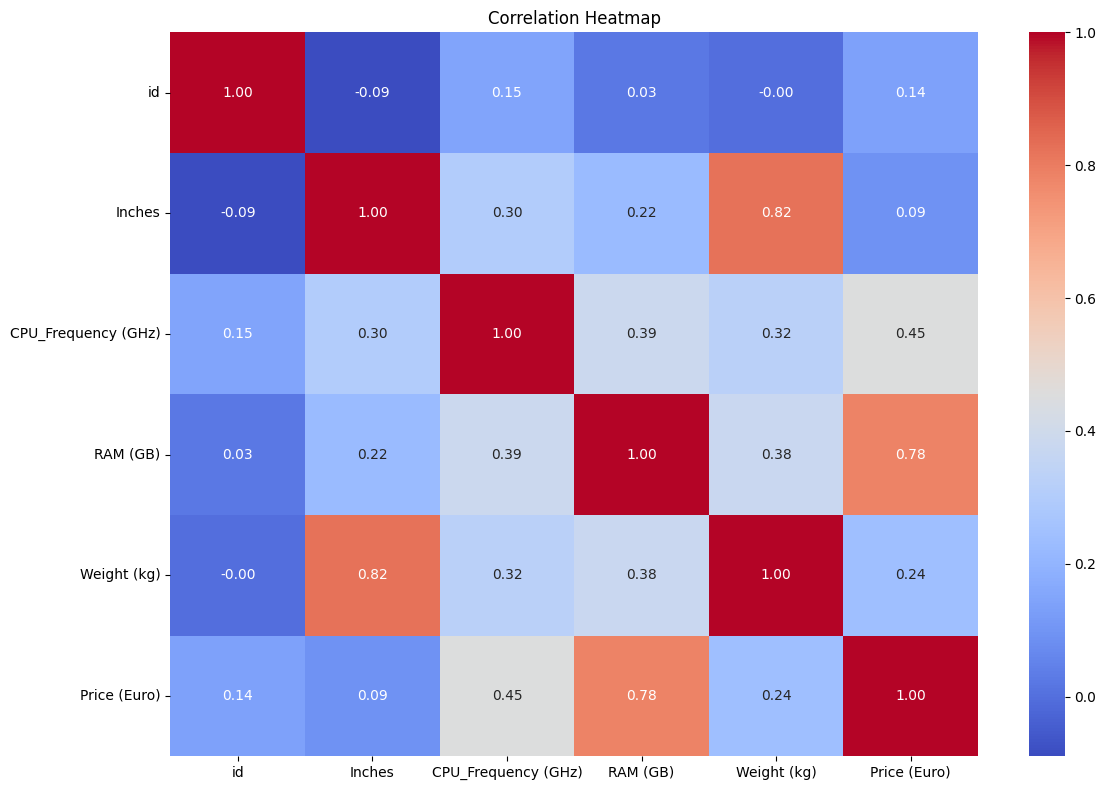

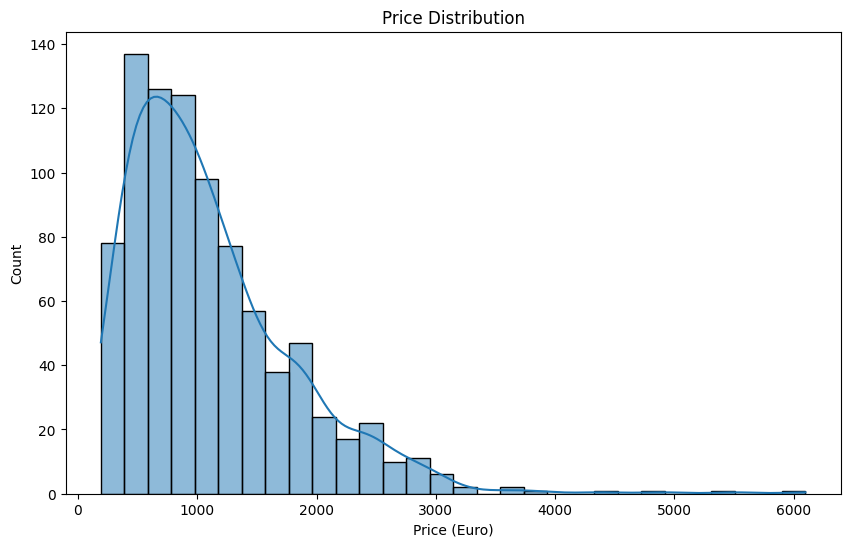

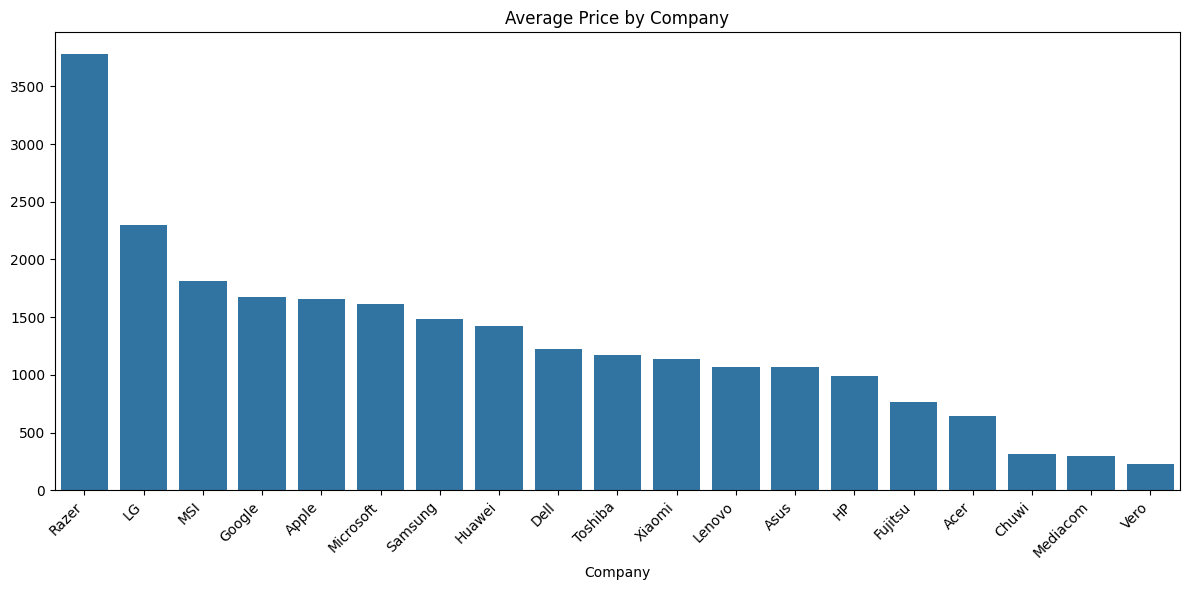

In [4]:

plt.figure(figsize=(12, 8))
numeric_cols = train.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    sns.heatmap(train[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(train["Price (Euro)"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price (Euro)")
plt.show()

if "Company" in train.columns:
    plt.figure(figsize=(12, 6))
    company_prices = train.groupby("Company")["Price (Euro)"].mean().sort_values(ascending=False)
    sns.barplot(x=company_prices.index, y=company_prices.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Average Price by Company")
    plt.tight_layout()
    plt.show()

if "Ram" in train.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=train, x="Ram", y="Price (Euro)", alpha=0.6)
    plt.title("RAM vs Price")
    plt.show()

if "Weight" in train.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=train, x="Weight", y="Price (Euro)", alpha=0.6)
    plt.title("Weight vs Price")
    plt.show()


In [5]:

def add_features(df):
    df = df.copy()

    if "Ram" in df.columns and "Weight" in df.columns:
        df["Ram_per_Weight"] = df["Ram"] / (df["Weight"] + 1e-6)

    if "Ram" in df.columns and "Inches" in df.columns:
        df["Ram_per_Inch"] = df["Ram"] / (df["Inches"] + 1e-6)

    if "CPU_Frequency" in df.columns and "Ram" in df.columns:
        df["CPUxRAM"] = df["CPU_Frequency"] * df["Ram"]

    if "Ram" in df.columns:
        df["Ram_Squared"] = df["Ram"] ** 2

    return df

train = add_features(train)
test = add_features(test)

In [6]:

TARGET = "Price (Euro)"
ID_COL = "id"

X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()

if ID_COL in test.columns:
    test_ids = test[ID_COL].copy()
else:
    test_ids = pd.Series(np.arange(len(test)), name="Id")

if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])
if ID_COL in test.columns:
    test = test.drop(columns=[ID_COL])

print("\nProcessed X shape:", X.shape)
print("Processed test shape:", test.shape)


Processed X shape: (881, 14)
Processed test shape: (394, 14)


In [7]:

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)




Categorical columns: ['Company', 'Product', 'TypeName', 'ScreenResolution', 'CPU_Company', 'CPU_Type', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys']
Numerical columns: ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)']


In [8]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nX_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", test.shape)



X_train shape: (704, 14)
X_val shape  : (177, 14)
X_test shape : (394, 14)


In [9]:

def evaluate_model(name, y_true, y_pred):
    """Calculate required metrics: RMSE, MAE, R2"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")

    return {"RMSE": rmse, "MAE": mae, "R2": r2}



In [10]:

linear_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

poly_model = Pipeline([
    ("prep", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

ridge_model = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge())
])

lasso_model = Pipeline([
    ("prep", preprocessor),
    ("model", Lasso(max_iter=20000))
])

tree_model = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

models = {
    "Linear Regression": linear_model,
    "Polynomial Regression (deg=2)": poly_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Decision Tree": tree_model
}



In [11]:

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    results[name] = evaluate_model(name, y_val, y_pred)




Training Linear Regression...

Linear Regression
-----------------
RMSE: 361.8341
MAE : 242.4847
R2  : 0.7863

Training Polynomial Regression (deg=2)...

Polynomial Regression (deg=2)
-----------------------------
RMSE: 315.7514
MAE : 184.8091
R2  : 0.8373

Training Ridge Regression...

Ridge Regression
----------------
RMSE: 227.9316
MAE : 165.3234
R2  : 0.9152

Training Lasso Regression...

Lasso Regression
----------------
RMSE: 281.2262
MAE : 204.9904
R2  : 0.8709

Training Decision Tree...

Decision Tree
-------------
RMSE: 335.6326
MAE : 216.5815
R2  : 0.8161



GENERATING LEARNING CURVE
Plotting learning curve for: Ridge Regression


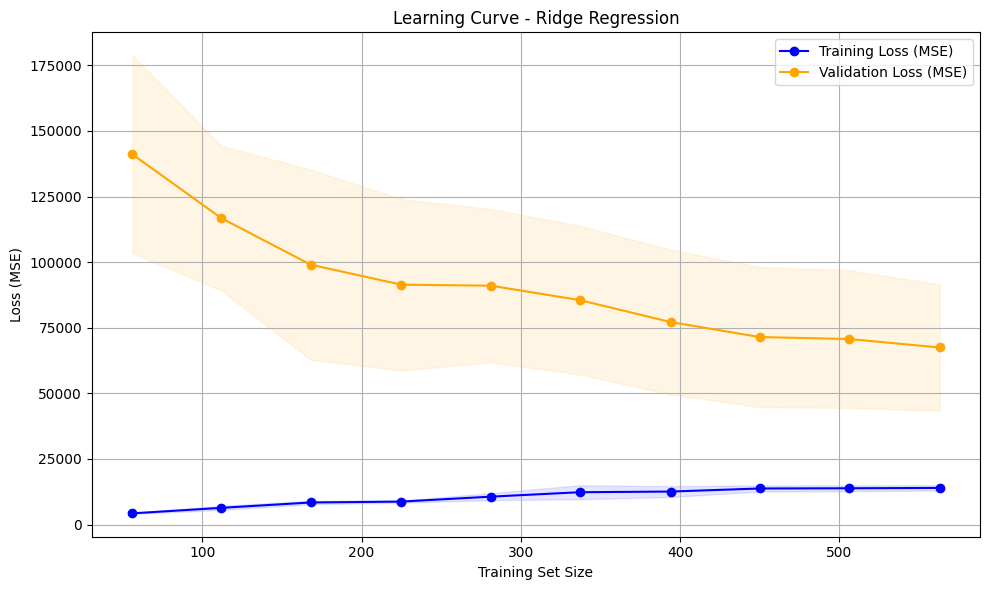

Final Training MSE: 13960.9235
Final Validation MSE: 67479.5646


In [12]:

print("\n" + "="*50)
print("GENERATING LEARNING CURVE")
print("="*50)

best_model_name = max(results, key=lambda x: results[x]["R2"])
best_model = models[best_model_name]

print(f"Plotting learning curve for: {best_model_name}")

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mse, 'o-', color="blue", label="Training Loss (MSE)")
plt.plot(train_sizes, val_mse, 'o-', color="orange", label="Validation Loss (MSE)")
plt.fill_between(train_sizes, train_mse - train_std, train_mse + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, val_mse - val_std, val_mse + val_std, alpha=0.1, color="orange")
plt.xlabel("Training Set Size")
plt.ylabel("Loss (MSE)")
plt.title(f"Learning Curve - {best_model_name}")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final Training MSE: {train_mse[-1]:.4f}")
print(f"Final Validation MSE: {val_mse[-1]:.4f}")


In [13]:

print("\n" + "="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

param_grid_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

print("\nTuning Ridge Regression...")
ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid_ridge,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

ridge_grid.fit(X_train, y_train)

print(f"Best Ridge Params: {ridge_grid.best_params_}")
print(f"Best CV Score (MSE): {-ridge_grid.best_score_:.4f}")

best_ridge = ridge_grid.best_estimator_
ridge_pred = best_ridge.predict(X_val)
ridge_tuned_results = evaluate_model("Tuned Ridge Regression", y_val, ridge_pred)

param_grid_tree = {
    "model__max_depth": [3, 5, 7, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8]
}

print("\nTuning Decision Tree...")
tree_grid = GridSearchCV(
    estimator=tree_model,
    param_grid=param_grid_tree,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

tree_grid.fit(X_train, y_train)

print(f"Best Tree Params: {tree_grid.best_params_}")
print(f"Best CV Score (MSE): {-tree_grid.best_score_:.4f}")

best_tree = tree_grid.best_estimator_
tree_pred = best_tree.predict(X_val)
tree_tuned_results = evaluate_model("Tuned Decision Tree", y_val, tree_pred)




HYPERPARAMETER TUNING

Tuning Ridge Regression...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Ridge Params: {'model__alpha': 1}
Best CV Score (MSE): 67479.8221

Tuned Ridge Regression
----------------------
RMSE: 227.9316
MAE : 165.3234
R2  : 0.9152

Tuning Decision Tree...
Fitting 5 folds for each of 112 candidates, totalling 560 fits
Best Tree Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
Best CV Score (MSE): 119222.4992

Tuned Decision Tree
-------------------
RMSE: 339.8832
MAE : 212.8366
R2  : 0.8114



MODEL COMPARISON
                        Model       RMSE        MAE       R2
             Ridge Regression 227.931590 165.323383 0.915192
       Tuned Ridge Regression 227.931590 165.323383 0.915192
             Lasso Regression 281.226198 204.990425 0.870897
Polynomial Regression (deg=2) 315.751405 184.809143 0.837252
                Decision Tree 335.632592 216.581497 0.816112
          Tuned Decision Tree 339.883240 212.836626 0.811425
            Linear Regression 361.834072 242.484665 0.786280


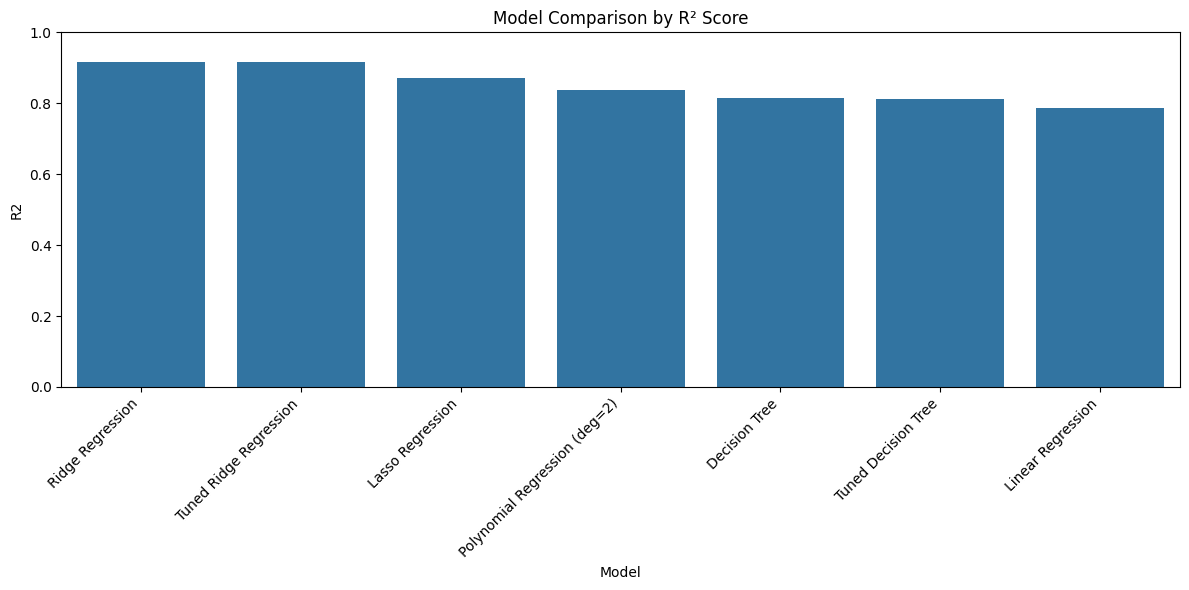

In [14]:

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        "Model": name,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R2": metrics["R2"]
    })

comparison_data.append({
    "Model": "Tuned Ridge Regression",
    "RMSE": ridge_tuned_results["RMSE"],
    "MAE": ridge_tuned_results["MAE"],
    "R2": ridge_tuned_results["R2"]
})

comparison_data.append({
    "Model": "Tuned Decision Tree",
    "RMSE": tree_tuned_results["RMSE"],
    "MAE": tree_tuned_results["MAE"],
    "R2": tree_tuned_results["R2"]
})

comparison_df = pd.DataFrame(comparison_data).sort_values("R2", ascending=False)
print(comparison_df.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="Model", y="R2")
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison by R² Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



In [15]:

all_results = {
    **results,
    "Tuned Ridge Regression": ridge_tuned_results,
    "Tuned Decision Tree": tree_tuned_results
}

final_model_name = max(all_results, key=lambda x: all_results[x]["R2"])

if "Tuned Ridge" in final_model_name:
    final_model = best_ridge
elif "Tuned Tree" in final_model_name:
    final_model = best_tree
else:
    final_model = models[final_model_name]

print(f"\nSelected Final Model: {final_model_name}")
print(f"Validation R2: {all_results[final_model_name]['R2']:.4f}")



Selected Final Model: Ridge Regression
Validation R2: 0.9152


In [16]:

print("\nTraining final model on full dataset...")
final_model.fit(X, y)


Training final model on full dataset...


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Inches',
                                                   'CPU_Frequency (GHz)',
                                                   'RAM (GB)', 'Weight (kg)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Company', 'Product',
                                                   'TypeName',
                                                   'ScreenResolution',
                                                   'CPU_Company', 'CPU_Type',
                                                   'Memory', 'GPU_Company',
                                                   'GPU_Type', 'OpSys'])])),
                ('model', Ridge())])

In [17]:

test_predictions = final_model.predict(test)

submission = pd.DataFrame({
    "Id": test_ids,
    "Price": test_predictions
})

submission.to_csv("submission.csv", index=False)
print(f"\nsubmission.csv created successfully!")
print(f"Shape: {submission.shape}")
print(f"\nFirst 5 rows of submission:")
print(submission.head())



submission.csv created successfully!
Shape: (394, 2)

First 5 rows of submission:
    Id        Price
0  882   841.742106
1  883   267.370117
2  884   937.042656
3  885   361.255199
4  886  1619.088979


In [18]:

comparison_df.to_csv("model_comparison.csv", index=False)
print("\nmodel_comparison.csv saved!")

if "Tree" in final_model_name:
    try:
        importances = final_model.named_steps['model'].feature_importances_
        feature_names = (numerical_cols +
                        list(final_model.named_steps['prep']
                            .named_transformers_['cat']
                            .named_steps['encoder']
                            .get_feature_names_out(categorical_cols)))

        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)

        importance_df.to_csv("feature_importance.csv", index=False)
        print("feature_importance.csv saved!")

        plt.figure(figsize=(10, 6))
        sns.barplot(data=importance_df.head(10), x='importance', y='feature')
        plt.title('Top 10 Feature Importances - Decision Tree')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not save feature importance: {e}")

print("\n" + "="*50)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("="*50)


model_comparison.csv saved!

PIPELINE COMPLETED SUCCESSFULLY
